# Linear Regression for Model Interpretabilty

## 1. Load Libraries and Dataset

In [1]:
#Import library and load dataset

import pandas as pd

df = pd.read_csv("data/bike+sharing+dataset/day.csv")

## 2. Getting Familiar with Dataset

In [2]:
df.shape

(731, 16)

In [3]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [5]:
df.nunique()

instant       731
dteday        731
season          4
yr              2
mnth           12
holiday         2
weekday         7
workingday      2
weathersit      3
temp          499
atemp         690
hum           595
windspeed     650
casual        606
registered    679
cnt           696
dtype: int64

## 3. Preprocess the Dataset

In [6]:
df["dteday"] = pd.to_datetime(df["dteday"])

In [7]:
df["cnt_2d_bfr"] = df["cnt"].shift(2)

In [8]:
# Denormalize 
df["temp"] = df["temp"] * 47 - 8
df["hum"] = df["hum"] * 100
df["windspeed"] = df["windspeed"] * 67

In [9]:
#Remove missing lag rows
df = df.dropna(subset=["cnt_2d_bfr"]).copy()

In [10]:
#Remove zero-humidity observation
df = df[df["hum"] != 0]  #as humidity is 0 which is not helpful

In [11]:
print(
    df[["dteday", "cnt", "hum", "cnt_2d_bfr"]]
    .loc[df["dteday"].between("2011-03-08", "2011-03-13")]
)

       dteday   cnt      hum  cnt_2d_bfr
66 2011-03-08  2133  42.0833       605.0
67 2011-03-09  1891  77.5417      1872.0
69 2011-03-11  1977  64.9565      1891.0
70 2011-03-12  2132  59.4583       623.0
71 2011-03-13  2417  52.7391      1977.0


### Preprocessing Notes

The raw UCI bike-sharing data stores `temp`, `hum`, and `windspeed` in normalized form. To follow the processed representation used in the book, we denormalize them as:

- `temp = temp × 47 − 8`
- `hum = hum × 100`
- `windspeed = windspeed × 67`

The order of preprocessing is important. `cnt_2d_bfr` is created **before** removing the observation with zero humidity. Therefore, the zero-humidity day's rental count can still appear as a two-day-before value for a later observation.

After dropping the two initial rows without `cnt_2d_bfr` and removing the zero-humidity observation, the dataset contains **728 observations**.

## 4. Select and Represent the Feature

In [12]:
#Features and target define
features = [
    "season",
    "holiday",
    "workingday",
    "weathersit",
    "temp",
    "hum",
    "windspeed",
    "cnt_2d_bfr"
]

X = df[features]
y = df["cnt"]

In [13]:
#Encoding categorical features

X_encoded = pd.get_dummies(
    X,
    columns=["season", "weathersit"],
    dtype=int
)

# Use Winter as reference for season
# Use Good as reference for weather
X_encoded = X_encoded.drop(columns=["season_4", "weathersit_1"])

In [14]:
#Renaming as we are following the book
X_encoded = X_encoded.rename(columns={
    "season_1": "seasonSPRING",
    "season_2": "seasonSUMMER",
    "season_3": "seasonFALL",
    "weathersit_2": "weatherMISTY",
    "weathersit_3": "weatherBAD",
})

### Feature Representation Notes

The model uses 8 original predictors:

`season`, `holiday`, `workingday`, `weathersit`, `temp`, `hum`, `windspeed`, and `cnt_2d_bfr`.

Categorical variables are represented with dummy variables. To match the book's interpretation:

- **Winter** is the reference category for `season`.
- **Good weather** is the reference category for `weather`.

Therefore the encoded features are `seasonSPRING`, `seasonSUMMER`, `seasonFALL`, `weatherMISTY`, and `weatherBAD`. The omitted reference categories are represented by all corresponding dummy variables being 0.

## 5. Train Linear Regression

In [15]:
#Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=1/3, random_state = 42)

In [16]:
#Fit model 
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
#Inspect the coefficients
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X_train.columns, model.coef_):
    print(f"{feature}: {coefficient:.2f}")

Intercept: 3208.683516356497
holiday: -635.76
workingday: 281.49
temp: 48.60
hum: -18.78
windspeed: -47.66
cnt_2d_bfr: 0.60
seasonSPRING: -625.77
seasonSUMMER: -180.75
seasonFALL: -409.96
weatherMISTY: -409.90
weatherBAD: -1959.87


### Interpreting the Coefficients

For a linear regression model,

$$\hat{y}=\beta_0+\beta_1x_1+\cdots+\beta_px_p$$

Each coefficient describes the expected change in the prediction for a one-unit increase in that feature, **holding the other features fixed**. For categorical variables, the coefficient is interpreted relative to the reference category.

Examples from our fitted model:

- `temp ≈ +48.6`: a 1°C increase is associated with about 48.6 additional predicted rentals, all else equal.
- `hum ≈ −18.8`: a 1 percentage-point increase in humidity is associated with about 18.8 fewer predicted rentals, all else equal.
- `windspeed ≈ −47.7`: a 1 km/h increase is associated with about 47.7 fewer predicted rentals, all else equal.
- `cnt_2d_bfr ≈ +0.60`: 100 additional rentals two days earlier correspond to about 60 additional predicted rentals, all else equal.

A coefficient's raw magnitude should **not** be used to compare importance across features with different units or scales.

## 6. Evalutate the Model

In [18]:
# Predict test data
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
})

print(comparison.head(10))

   actual    predicted
0    1746  2567.162370
1    3811  3976.309896
2    3068  3071.295044
3    6855  5927.752072
4    6241  7074.406445
5    4765  5290.990181
6     441  -936.823378
7    7538  7248.677883
8    4036  3374.122962
9    3577  4006.887117


In [19]:
# Calculating test error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 706.2129852620225
RMSE: 903.5740835363233
R²  : 0.7814847275280266


## 7. Interpret the Linear Model

### Why We Use `statsmodels` Here

`scikit-learn` gives us the fitted coefficients and predictions, but it does not directly provide the standard errors used in the book's coefficient table. We therefore fit the same training data with `statsmodels.OLS` to obtain:

- coefficient (`coef` / Estimate)
- standard error (`std err`)
- t statistic (`t`)
- confidence interval

The OLS model is fitted on the **training set**, so its training $R^2$ should not be confused with the test-set $R^2$ reported earlier.

In [20]:
#Coefficient Table
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)

ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     122.4
Date:                Fri, 11 Sep 2026   Prob (F-statistic):          1.01e-130
Time:                        12:24:13   Log-Likelihood:                -4026.3
No. Observations:                 485   AIC:                             8077.
Df Residuals:                     473   BIC:                             8127.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         3208.6835    371.796      8.630   

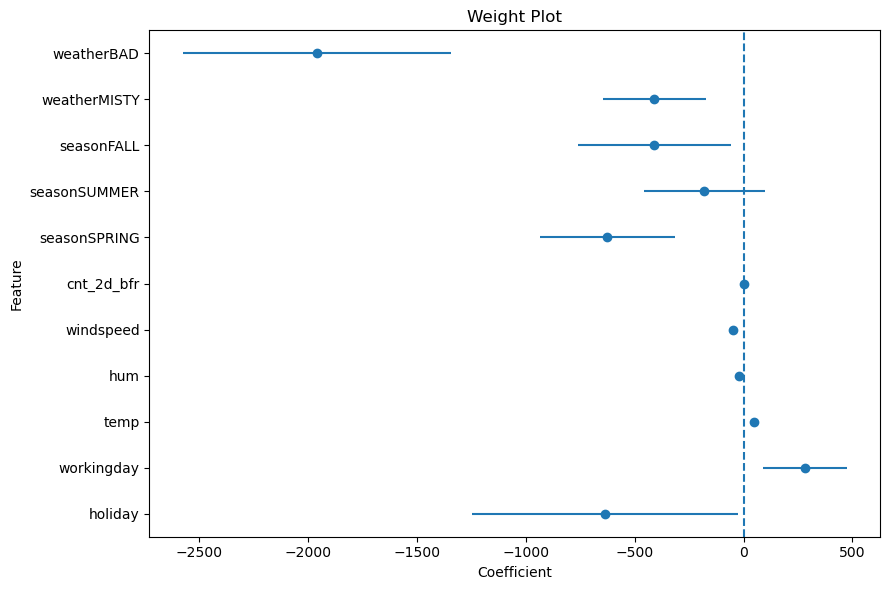

In [21]:
#Weight plot - weight and variance estimates
import matplotlib.pyplot as plt

coef = ols_model.params.drop("const")
conf_int = ols_model.conf_int().drop("const")

errors = [
    coef - conf_int[0],
    conf_int[1] - coef
]

plt.figure(figsize=(9, 6))

plt.errorbar(
    coef.values,
    coef.index,
    xerr=errors,
    fmt="o"
)

plt.axvline(0, linestyle="--")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Weight Plot")
plt.tight_layout()
plt.show()

### Weight Plot: What It Shows

The weight plot visualizes the learned coefficient for each feature together with its 95% confidence interval.

- A coefficient to the right of 0 indicates a positive association.
- A coefficient to the left of 0 indicates a negative association.
- If the confidence interval crosses 0, the data do not give strong evidence that the coefficient differs from 0 at the 95% level.

The weight plot answers: **"What is the model's estimated weight for each feature?"** It does not directly show the size of that feature's contribution for a particular observation.

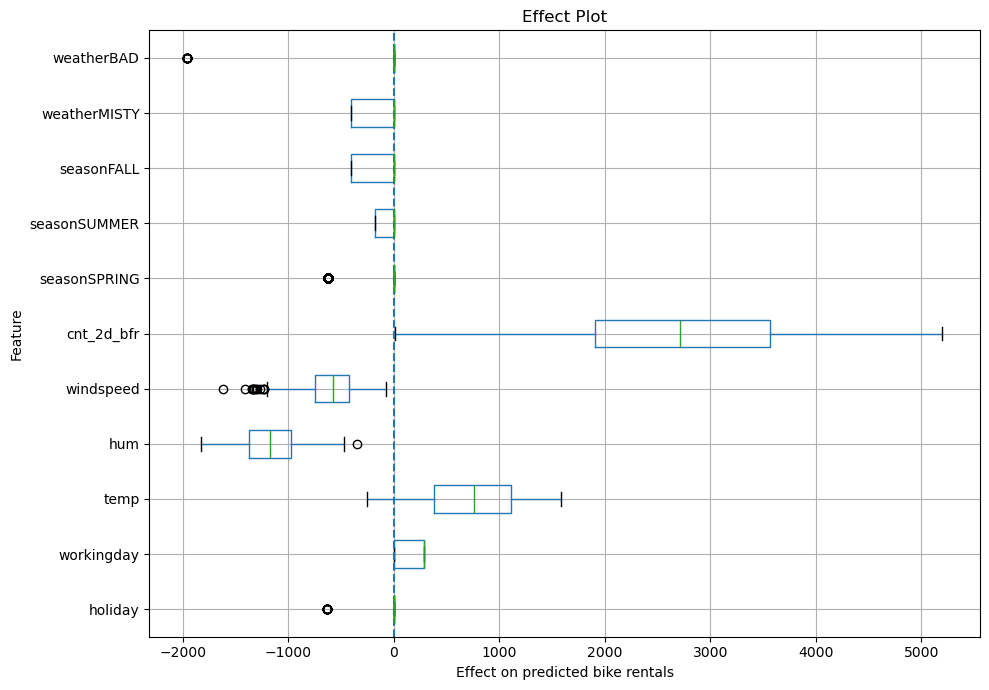

In [22]:
# Effect plot - 
effects = X_encoded * model.coef_

plt.figure(figsize=(10, 7))

effects.boxplot(
    vert=False
)

plt.axvline(0, linestyle="--")
plt.xlabel("Effect on predicted bike rentals")
plt.ylabel("Feature")
plt.title("Effect Plot")
plt.tight_layout()
plt.show()

### Effect Plot: From Weights to Contributions

For observation $i$, the contribution of feature $j$ is:

$$\text{effect}_{ij}=\beta_jx_{ij}$$

The effect plot applies this calculation across the observations and shows the distribution of feature contributions.

This is useful because coefficient magnitudes are measured per feature unit. For example, `cnt_2d_bfr` has a small coefficient of about 0.60, but its values are in the hundreds or thousands, so its actual contribution can be large.

The intercept is a baseline term and is not included in the feature-effect boxplots.

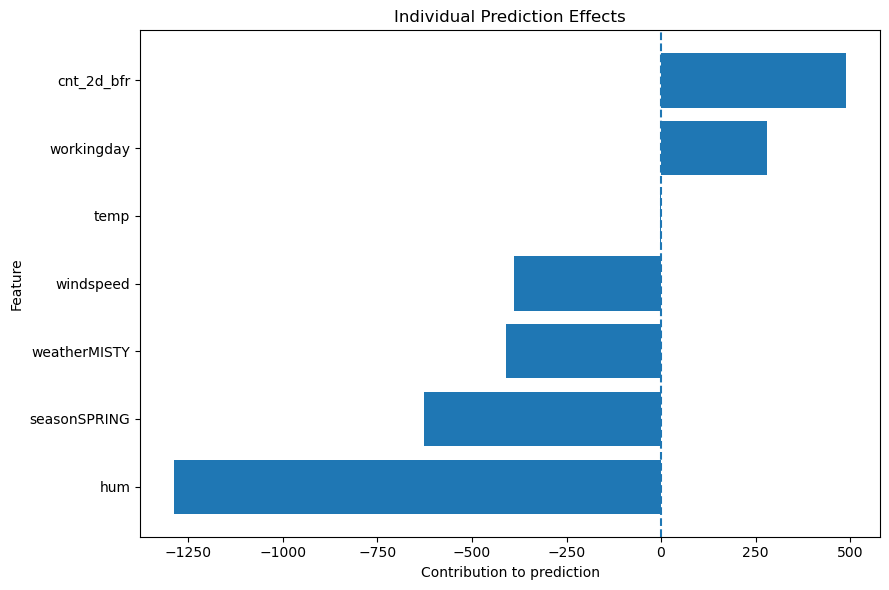

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

instance = X_encoded.loc[df["cnt"] == 1263]
instance_effects = instance.iloc[0] * model.coef_
prediction = model.predict(instance)[0]
reconstructed = model.intercept_ + instance_effects.sum()

# Keep only non-zero feature effects
plot_effects = instance_effects[instance_effects != 0].sort_values()

plt.figure(figsize=(9, 6))

plt.barh(
    plot_effects.index,
    plot_effects.values
)

plt.axvline(0, linestyle="--")

plt.xlabel("Contribution to prediction")
plt.ylabel("Feature")
plt.title("Individual Prediction Effects")
plt.tight_layout()
plt.show()

### Individual Prediction: Why One Observation Was Predicted This Way

For one selected observation, the linear model can be decomposed exactly as:

$$\hat{y}=\beta_0+\sum_j\beta_jx_j$$

So the prediction is the intercept plus the individual feature effects. For the selected day (`cnt = 1263`), our calculated feature contributions reconstruct the model prediction of approximately **1263.12** exactly up to floating-point precision.

This demonstrates the central idea of an individual explanation for an inherently interpretable linear model: we can see how each feature pushed the prediction upward or downward.

## 8. Explain individual predictions with effect plots

In [24]:

effect_plot_data = pd.DataFrame({
    "holiday": effects["holiday"],
    "workingday": effects["workingday"],
    "temp": effects["temp"],
    "hum": effects["hum"],
    "windspeed": effects["windspeed"],
    "cnt_2d_bfr": effects["cnt_2d_bfr"],
    "season": effects[
        ["seasonSPRING", "seasonSUMMER", "seasonFALL"]
    ].sum(axis=1),
    "weather": effects[
        ["weatherMISTY", "weatherBAD"]
    ].sum(axis=1)
})

In [25]:
instance_plot_effects = pd.Series({
    "holiday": instance_effects["holiday"],
    "workingday": instance_effects["workingday"],
    "temp": instance_effects["temp"],
    "hum": instance_effects["hum"],
    "windspeed": instance_effects["windspeed"],
    "cnt_2d_bfr": instance_effects["cnt_2d_bfr"],
    "season": instance_effects[
        ["seasonSPRING", "seasonSUMMER", "seasonFALL"]
    ].sum(),
    "weather": instance_effects[
        ["weatherMISTY", "weatherBAD"]
    ].sum()
})

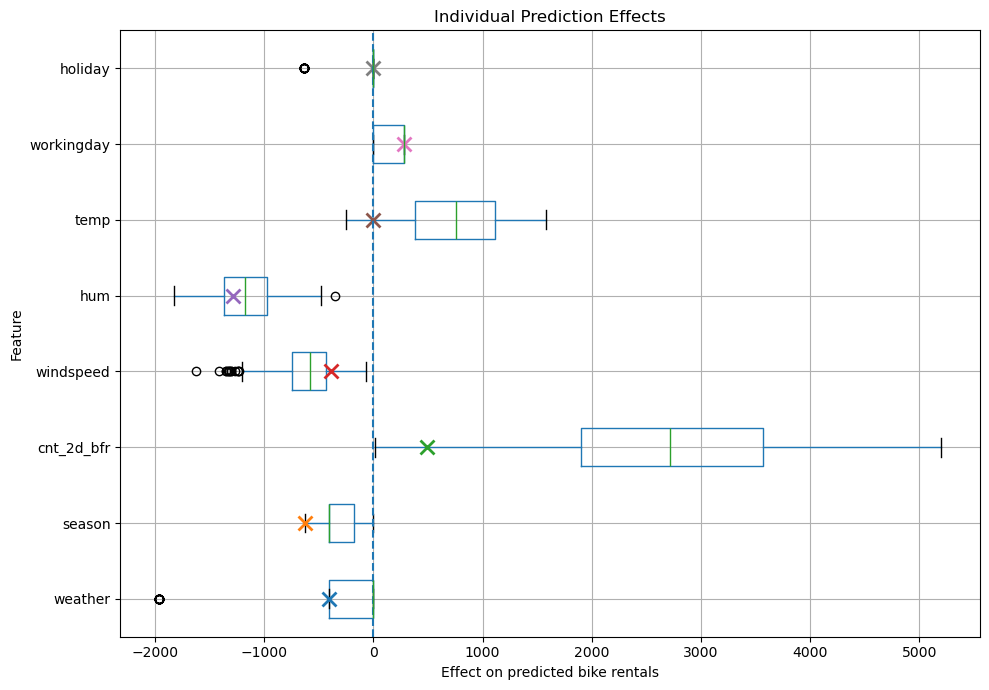

In [26]:
features_order = [
    "weather",
    "season",
    "cnt_2d_bfr",
    "windspeed",
    "hum",
    "temp",
    "workingday",
    "holiday"
]

plot_data = effect_plot_data[features_order]

fig, ax = plt.subplots(figsize=(10, 7))

# Boxplots for all observations
plot_data.boxplot(
    vert=False,
    ax=ax
)

# Individual instance effects as crosses
y_positions = range(1, len(features_order) + 1)

for y_pos, feature in zip(y_positions, features_order):
    ax.plot(
        instance_plot_effects[feature],
        y_pos,
        marker="x",
        markersize=10,
        markeredgewidth=2
    )

ax.axvline(0, linestyle="--")

ax.set_xlabel("Effect on predicted bike rentals")
ax.set_ylabel("Feature")
ax.set_title("Individual Prediction Effects")
plt.tight_layout()
plt.show()

## 9. Key Takeways

### 1. A linear regression model is inherently interpretable

The prediction is an explicit sum of an intercept and feature contributions. We can inspect the coefficients directly instead of needing a separate explanation algorithm.

### 2. Coefficients and effects answer different questions

The **weight plot** shows the learned coefficient and its uncertainty. The **effect plot** shows how much the feature actually contributes across the observed data.

### 3. Feature scales matter

A coefficient such as `0.60` for `cnt_2d_bfr` can still produce a large contribution because the feature itself can be thousands of rentals. Raw coefficient magnitudes should therefore not be compared blindly across differently scaled variables.

### 4. Reference categories are essential for categorical interpretation

`seasonSPRING`, `seasonSUMMER`, and `seasonFALL` are interpreted relative to **Winter**, while `weatherMISTY` and `weatherBAD` are interpreted relative to **Good weather**.

### 5. An individual prediction can be decomposed

For a selected observation, each feature contributes `coefficient × feature value`, and these contributions plus the intercept reconstruct the prediction. This gives a direct, human-readable explanation of the model's decision.

### 6. Evaluation and explanation are different tasks

Our test-set metrics (`MAE`, `RMSE`, and test $R^2$) describe predictive performance. The coefficient table, weight plot, effect plot, and individual effects describe **why the model predicts what it predicts**.

### 7. The book and our notebook need not produce identical coefficients

We use a reproducible `train_test_split` with `random_state=42`. The book's published coefficient table comes from its own train/test procedure, so the exact numerical coefficients need not match. The important goal here is to reproduce the book's **data-processing logic and interpretation concepts**, not to tune a random seed until the numbers match.

### 8. Linear regression has limitations

Because ordinary linear regression is unconstrained, it can produce unrealistic values such as a negative rental prediction. The model is useful for learning interpretability, but predictive performance and model assumptions still need to be considered.

### Connection to LIME

This notebook does **not** implement LIME. It prepares the conceptual foundation for LIME by showing what a transparent local explanation looks like when the model itself exposes its coefficients. LIME becomes useful when the original model is a black box and we need a local interpretable surrogate instead.